# Taller de Visualización de Datos

1. Importe los datos de S8_Ventas.csv y observe las categorías y tipos para realizar los análisis

2. Genere las siguientes visualizaciones básicas a partir de los datos

* Histograma: Distribución de ventas
* Diagrama de Caja: Ventas por región
* Diagrama de Dispersión: Ventas por año y categoría

3. Genere la siguiente visualizaciones avanzadas:

* Serie de Tiempo: grafique la evolución de ventas anuales
* Mapa de Calor: mostrar ventas promedio por región y categoría
Sugerencia: Cree una tabla dinámica usando la función pivot_table

4. Preguntas de Interpretación de Conceptos

* ¿Qué información revela el histograma sobre la distribución de ventas?
* ¿Cómo interpretar un diagrama de caja?
* ¿Qué patrones identificas en el mapa de calor?
* ¿Cómo cambian las ventas a través de los años?




# **2. visualizaciones: Histograma, Diagrama de Caja y Diagrama de Dispersion**

* Histograma: Distribución de ventas
* Diagrama de Caja: Ventas por región
* Diagrama de Dispersión: Ventas por año y categoría

Datos importados exitosamente.

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Región     120 non-null    object
 1   Año        120 non-null    int64 
 2   Ventas     120 non-null    int64 
 3   Categoría  120 non-null    object
dtypes: int64(2), object(2)
memory usage: 3.9+ KB

Primeras 5 filas del DataFrame:
  Región   Año  Ventas    Categoría
0  Norte  2020  171958  Electrónica
1    Sur  2020  196867     Deportes
2   Este  2020  181932     Deportes
3  Oeste  2020  415838     Deportes
4  Norte  2020  309178    Alimentos


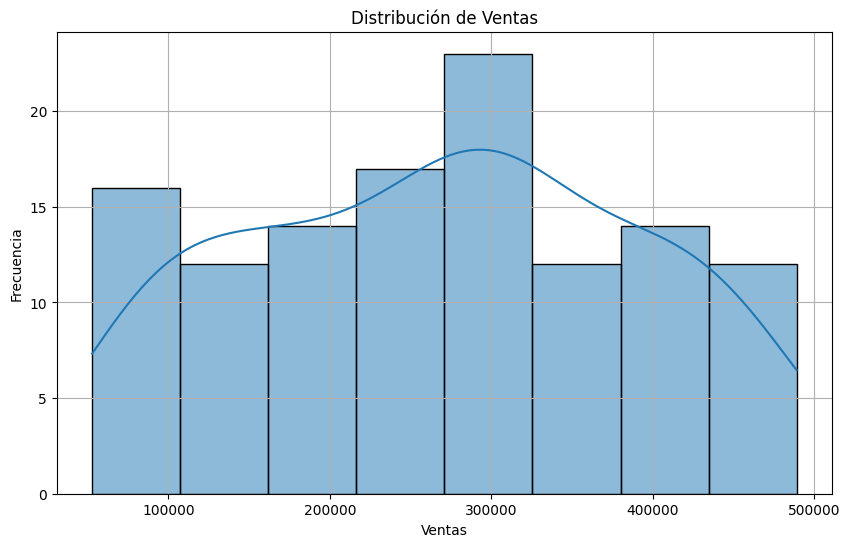

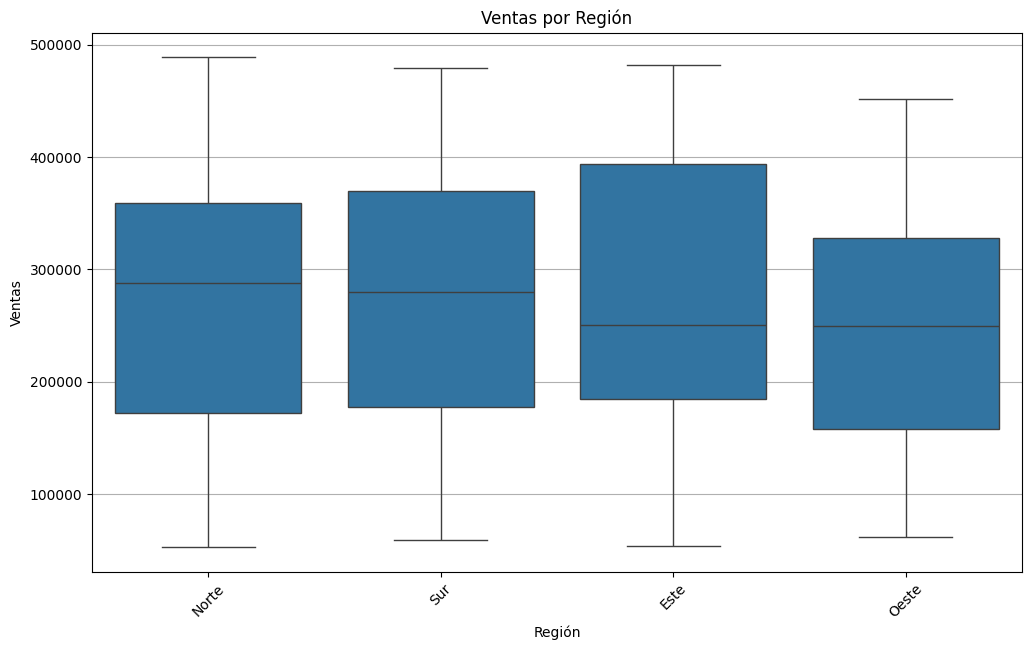

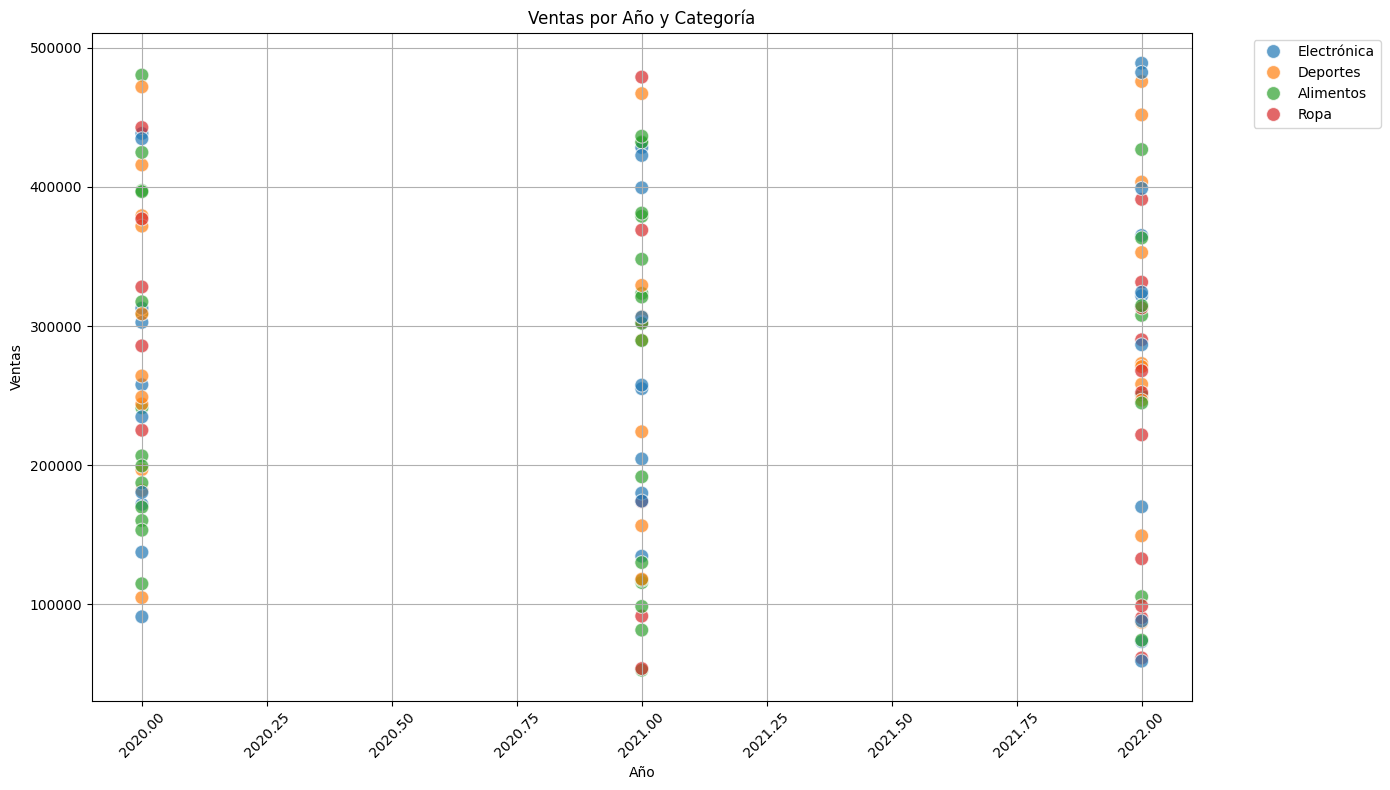

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Importar los datos y observar categorías y tipos
file_path = 'S8_Ventas.csv'
try:
    df = pd.read_csv(file_path)
    print("Datos importados exitosamente.")
    print("\nInformación del DataFrame:")
    df.info()
    print("\nPrimeras 5 filas del DataFrame:")
    print(df.head())

    # Asegurarse de que la columna 'Ventas' sea numérica
    if 'Ventas' in df.columns:
        df['Ventas'] = pd.to_numeric(df['Ventas'], errors='coerce')
        df.dropna(subset=['Ventas'], inplace=True)
    else:
        print("Advertencia: La columna 'Ventas' no se encontró. No se pueden generar visualizaciones de ventas.")
        raise ValueError("Columna 'Ventas' no encontrada.")

    # Convertir columna de fecha a datetime y extraer el año si existe una columna de fecha común
    # Asumiendo que puede haber una columna como 'Fecha' o 'OrderDate' o similar
    date_column = None
    for col in df.columns:
        if 'fecha' in col.lower() or 'date' in col.lower():
            date_column = col
            break

    if date_column and pd.api.types.is_object_dtype(df[date_column]):
        try:
            df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
            df['Año'] = df[date_column].dt.year
            df.dropna(subset=['Año'], inplace=True)
            print(f"Columna '{date_column}' convertida a tipo fecha y 'Año' extraído.")
        except Exception as e:
            print(f"No se pudo convertir la columna '{date_column}' a fecha. Error: {e}")
            df['Año'] = 0
    elif 'Año' not in df.columns:
        print("Advertencia: No se encontró una columna de fecha para extraer el año y tampoco una columna 'Año' existente.")
        print("El diagrama de dispersión por año no podrá ser generado correctamente.")
        df['Año'] = 0

    # 2. Generar visualizaciones básicas

    # Histograma: Distribución de ventas
    plt.figure(figsize=(10, 6))
    sns.histplot(df['Ventas'], kde=True)
    plt.title('Distribución de Ventas')
    plt.xlabel('Ventas')
    plt.ylabel('Frecuencia')
    plt.grid(True)
    plt.show()

    # Diagrama de Caja: Ventas por región
    if 'Región' in df.columns:
        plt.figure(figsize=(12, 7))
        sns.boxplot(x='Región', y='Ventas', data=df)
        plt.title('Ventas por Región')
        plt.xlabel('Región')
        plt.ylabel('Ventas')
        plt.xticks(rotation=45)
        plt.grid(axis='y')
        plt.show()
    else:
        print("Advertencia: La columna 'Región' no se encontró. No se puede generar el diagrama de caja por región.")

    # Diagrama de Dispersión: Ventas por año y categoría
    if 'Año' in df.columns and 'Categoría' in df.columns and df['Año'].max() > 1900:
        plt.figure(figsize=(14, 8))
        sns.scatterplot(x='Año', y='Ventas', hue='Categoría', data=df, s=100, alpha=0.7)
        plt.title('Ventas por Año y Categoría')
        plt.xlabel('Año')
        plt.ylabel('Ventas')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Advertencia: No se pueden generar el diagrama de dispersión. Asegúrese de que existen las columnas 'Año' y 'Categoría' y que 'Año' contiene valores válidos.")

except FileNotFoundError:
    print(f"Error: El archivo '{file_path}' no se encontró. Por favor, asegúrese de que el archivo esté cargado en el entorno de Colab.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

# **3. Genere la siguiente visualizaciones avanzadas:**
* Serie de Tiempo: grafique la evolución de ventas anuales
* Mapa de Calor: mostrar ventas promedio por región y categoría
Sugerencia: Cree una tabla dinámica usando la función pivot_table

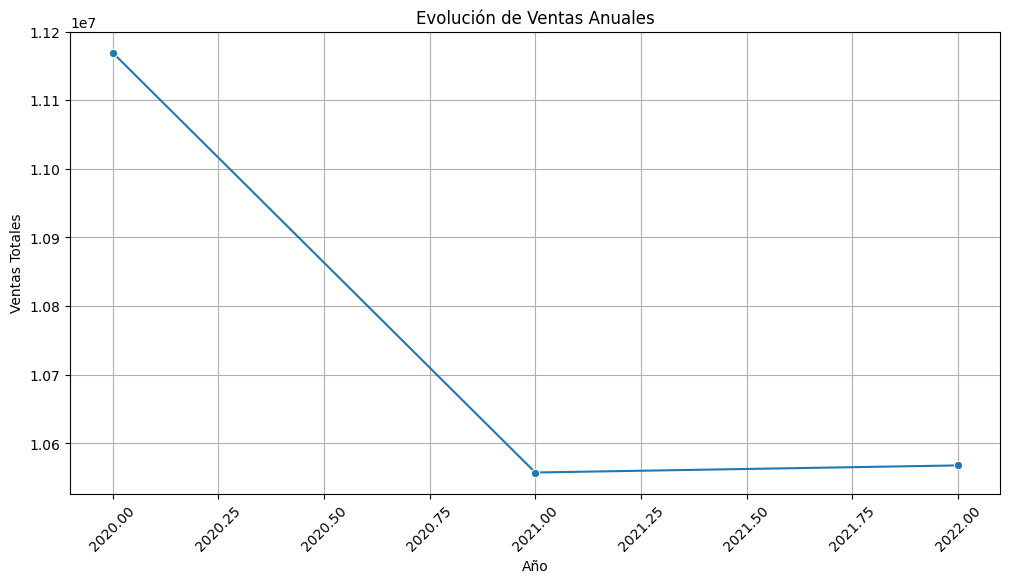

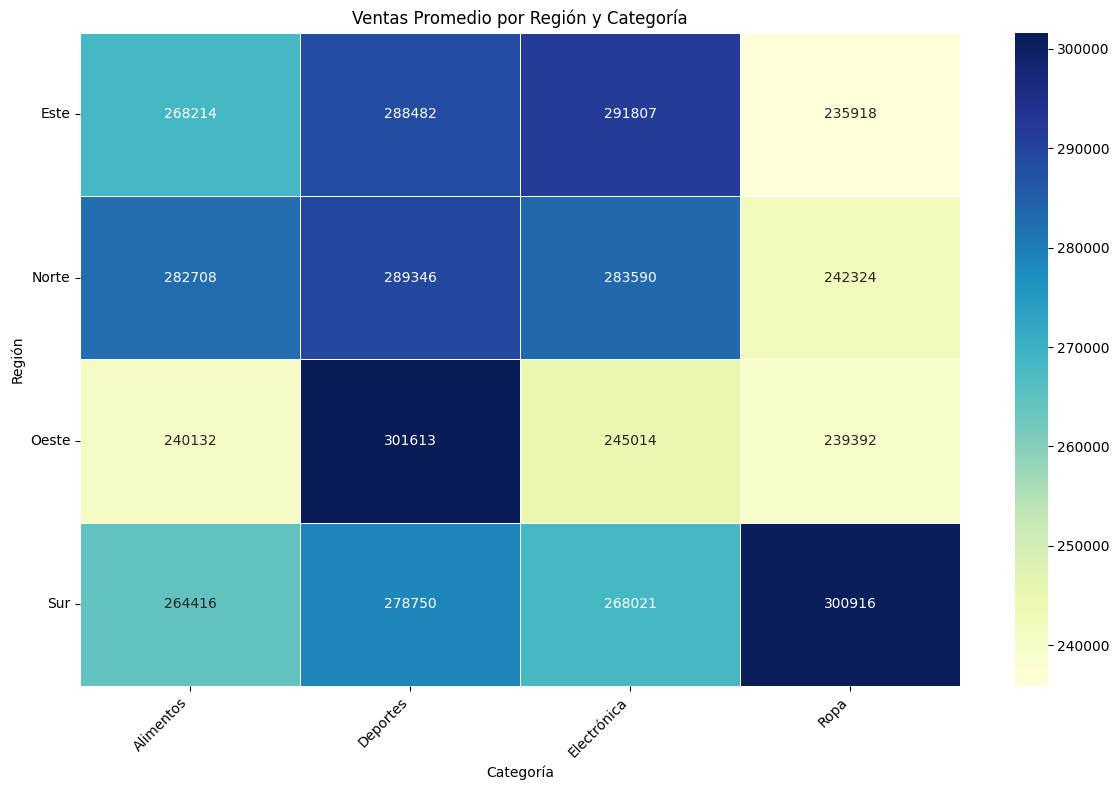

In [4]:
# Serie de Tiempo: graficar la evolución de ventas anuales
if 'Año' in df.columns and 'Ventas' in df.columns:
    ventas_anuales = df.groupby('Año')['Ventas'].sum().reset_index()
    plt.figure(figsize=(12, 6))
    sns.lineplot(x='Año', y='Ventas', data=ventas_anuales, marker='o')
    plt.title('Evolución de Ventas Anuales')
    plt.xlabel('Año')
    plt.ylabel('Ventas Totales')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Advertencia: Las columnas 'Año' o 'Ventas' no se encontraron para generar la serie de tiempo.")

# Mapa de Calor: mostrar ventas promedio por región y categoría
if 'Región' in df.columns and 'Categoría' in df.columns and 'Ventas' in df.columns:
    ventas_pivot = df.pivot_table(index='Región', columns='Categoría', values='Ventas', aggfunc='mean')

    plt.figure(figsize=(12, 8))
    sns.heatmap(ventas_pivot, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
    plt.title('Ventas Promedio por Región y Categoría')
    plt.xlabel('Categoría')
    plt.ylabel('Región')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Advertencia: Las columnas 'Región', 'Categoría' o 'Ventas' no se encontraron para generar el mapa de calor.")

# **4. Preguntas de Interpretación de Conceptos**

* ¿Qué información revela el histograma sobre la distribución de ventas?
* ¿Cómo interpretar un diagrama de caja?
* ¿Qué patrones identificas en el mapa de calor?
* ¿Cómo cambian las ventas a través de los años?


**¿Qué información revela el histograma sobre la distribución de ventas?**

El histograma muestra la distribucion de las ventas, se puede ver si las ventas se agrupan alrededor de un valor central, si hay muchas ventas bajas y pocas altas, o viceversa, o si hay multiples picos que podrian indicar diferentes grupos de ventas.

**¿Cómo interpretar un diagrama de caja?**

El diagrama de caja te permite visualizar la distribuscion de las ventas para cada region en este caso. Donde, la caja central representa el rango intercuartilico, donde estan ubicados el 50% de los datos. la linea dentro de la caja es la mediana. Y los extremos se extienden hasta el minimo y maximo de los datos, excluyendo los valores atipicos que se muestran como puntos individuales.

**¿Qué patrones identificas en el mapa de calor?**

El mapa de calor de ventas promedio por region y categoria te permite identificar donde se concentran las ventas mas altas y mas bajas de cada region y cada articulo, donde el que mayores vendas tubo fue el Oeste en Deportes con 301613 ventas en promedio, y las menores ventas fueron en el Este en Ropa con 235918 ventas en promedio.

**¿Cómo cambian las ventas a través de los años?**

Las ventas totales fueron bajando proceduralmente desde el año 2020.00 hasta el 2021.00 donde cambiaron su trayectoria a una de aumento leve hasta el año 2022.
